In [1]:
from textblob import TextBlob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Тестируем на простых примерах
texts = [
    "AI is transforming education and creating amazing opportunities for students",
    "AI is replacing teachers and destroying human connection in schools",
    "AI tools help students learn faster but we don't know the long-term effects",
    "Children are becoming dependent on AI and losing critical thinking skills",
    "AI democratizes access to quality education for children in poor countries"
]

for text in texts:
    blob = TextBlob(text)
    sentiment = blob.sentiment.polarity  # -1 (негатив) до +1 (позитив)
    print(f"Score: {sentiment:+.2f} | {text[:60]}...")

Score: +0.60 | AI is transforming education and creating amazing opportunit...
Score: -0.10 | AI is replacing teachers and destroying human connection in ...
Score: +0.00 | AI tools help students learn faster but we don't know the lo...
Score: +0.23 | Children are becoming dependent on AI and losing critical th...
Score: -0.40 | AI democratizes access to quality education for children in ...


In [2]:
# Посмотрим что именно TextBlob "видит" в словах
from textblob import Word

words = ['amazing', 'destroying', 'democratizes', 'dependent', 'transforming']
for word in words:
    w = Word(word)
    blob_check = TextBlob(word)
    print(f"{word}: {blob_check.sentiment.polarity:+.2f}")

amazing: +0.60
destroying: -0.20
democratizes: +0.00
dependent: +0.00
transforming: +0.00


In [3]:
# Разбиваем фразу на части чтобы найти проблемное слово
phrase = "AI democratizes access to quality education for children in poor countries"
words = phrase.split()

for i in range(len(words)):
    partial = ' '.join(words[:i+1])
    score = TextBlob(partial).sentiment.polarity
    if score != 0:
        print(f"Score изменился на {score:+.2f} после слова: '{words[i]}'")

Score изменился на -0.40 после слова: 'poor'
Score изменился на -0.40 после слова: 'countries'


In [5]:
from transformers import pipeline

# Загружаем модель которая понимает контекст
# Первый раз скачивает ~250MB - займёт минуту
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

print("Модель загружена!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Модель загружена!


In [6]:
texts = [
    "AI is transforming education and creating amazing opportunities for students",
    "AI is replacing teachers and destroying human connection in schools",
    "AI tools help students learn faster but we don't know the long-term effects",
    "Children are becoming dependent on AI and losing critical thinking skills",
    "AI democratizes access to quality education for children in poor countries"
]

print("СРАВНЕНИЕ: TextBlob vs Transformer\n")
print(f"{'Text':<55} {'TextBlob':>10} {'Transformer':>12}")
print("-" * 80)

for text in texts:
    # TextBlob
    tb_score = TextBlob(text).sentiment.polarity
    
    # Transformer
    result = sentiment_pipeline(text)[0]
    tr_label = result['label']
    tr_score = result['score'] if tr_label == 'POSITIVE' else -result['score']
    
    print(f"{text[:54]:<55} {tb_score:>+10.2f} {tr_score:>+12.2f}")

СРАВНЕНИЕ: TextBlob vs Transformer

Text                                                      TextBlob  Transformer
--------------------------------------------------------------------------------
AI is transforming education and creating amazing oppo       +0.60        +1.00
AI is replacing teachers and destroying human connecti       -0.10        -1.00
AI tools help students learn faster but we don't know        +0.00        -1.00
Children are becoming dependent on AI and losing criti       +0.23        -1.00
AI democratizes access to quality education for childr       -0.40        -0.81


In [7]:
narratives = [
    {"year": 2015, "source": "policy", "text": "Technology in classrooms will improve student outcomes"},
    {"year": 2015, "source": "media", "text": "Screens are replacing teachers and harming children"},
    {"year": 2018, "source": "policy", "text": "AI tutors can personalize learning for every student"},
    {"year": 2018, "source": "media", "text": "AI is making students lazy and unable to think independently"},
    {"year": 2020, "source": "policy", "text": "Digital education saved learning during the pandemic"},
    {"year": 2020, "source": "media", "text": "Remote learning devastated children's social development"},
    {"year": 2023, "source": "policy", "text": "AI tools help teachers identify struggling students early"},
    {"year": 2023, "source": "media", "text": "Students use AI to cheat and avoid real learning"},
]

df_narratives = pd.DataFrame(narratives)

# Добавляем sentiment
df_narratives['sentiment'] = df_narratives['text'].apply(
    lambda x: sentiment_pipeline(x)[0]['score'] * 
    (1 if sentiment_pipeline(x)[0]['label'] == 'POSITIVE' else -1)
)

print(df_narratives[['year', 'source', 'sentiment', 'text']].to_string(index=False))

 year source  sentiment                                                         text
 2015 policy   0.999330       Technology in classrooms will improve student outcomes
 2015  media  -0.999323          Screens are replacing teachers and harming children
 2018 policy   0.980656         AI tutors can personalize learning for every student
 2018  media  -0.999667 AI is making students lazy and unable to think independently
 2020 policy   0.955680         Digital education saved learning during the pandemic
 2020  media  -0.998439     Remote learning devastated children's social development
 2023 policy   0.953612    AI tools help teachers identify struggling students early
 2023  media  -0.999680             Students use AI to cheat and avoid real learning


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Тренд по годам для policy vs media
for source, color in [('policy', 'green'), ('media', 'red')]:
    data = df_narratives[df_narratives['source'] == source]
    ax1.plot(data['year'], data['sentiment'], 
             marker='o', linewidth=2, color=color, label=source)

ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax1.set_xlabel('Год')
ax1.set_ylabel('Sentiment (-1 негатив, +1 позитив)')
ax1.set_title('Нарративы об AI в образовании:\nPolicy vs Media 2015–2023')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Средний sentiment по источникам
avg_sentiment = df_narratives.groupby('source')['sentiment'].mean()
colors = ['red' if v < 0 else 'green' for v in avg_sentiment.values]
ax2.bar(avg_sentiment.index, avg_sentiment.values, color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax2.set_ylabel('Средний sentiment')
ax2.set_title('Policy vs Media:\nсредняя тональность нарратива')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPolicy средний sentiment: {df_narratives[df_narratives['source

SyntaxError: unterminated string literal (detected at line 28) (3672495541.py, line 28)

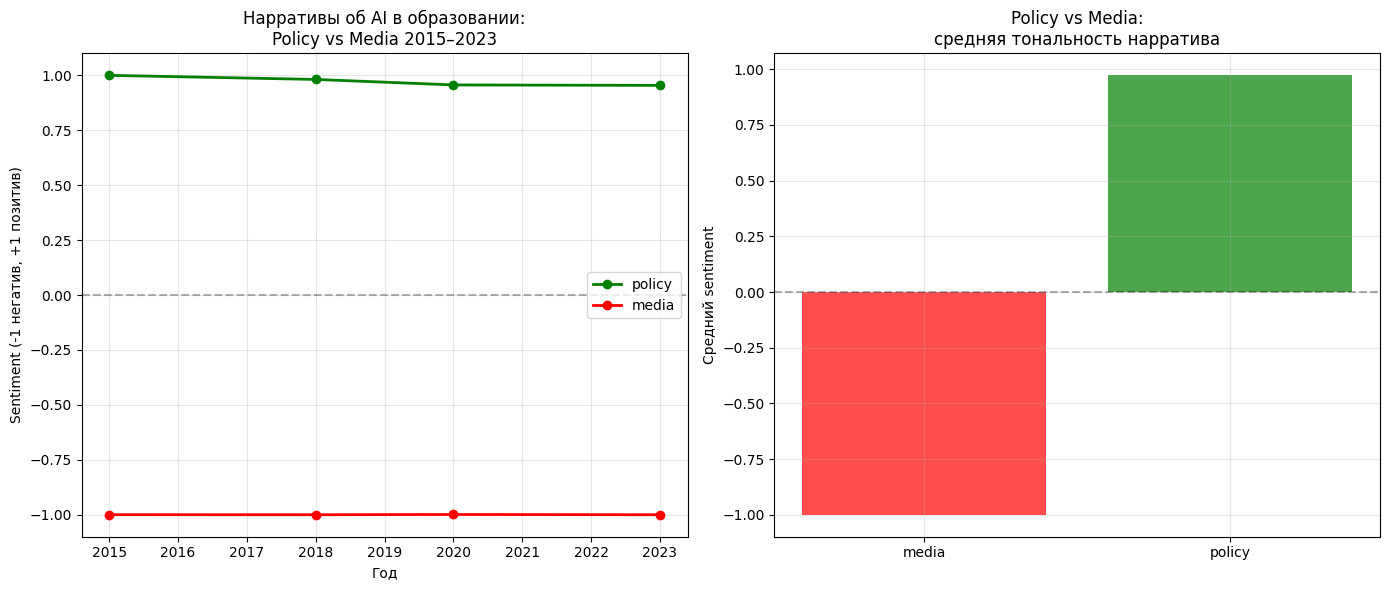


Policy средний sentiment: +0.972
Media средний sentiment: -0.999


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Тренд по годам для policy vs media
for source, color in [('policy', 'green'), ('media', 'red')]:
    data = df_narratives[df_narratives['source'] == source]
    ax1.plot(data['year'], data['sentiment'], 
             marker='o', linewidth=2, color=color, label=source)

ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax1.set_xlabel('Год')
ax1.set_ylabel('Sentiment (-1 негатив, +1 позитив)')
ax1.set_title('Нарративы об AI в образовании:\nPolicy vs Media 2015–2023')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Средний sentiment по источникам
avg_sentiment = df_narratives.groupby('source')['sentiment'].mean()
colors = ['red' if v < 0 else 'green' for v in avg_sentiment.values]
ax2.bar(avg_sentiment.index, avg_sentiment.values, color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax2.set_ylabel('Средний sentiment')
ax2.set_title('Policy vs Media:\nсредняя тональность нарратива')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPolicy средний sentiment: {df_narratives[df_narratives['source']=='policy']['sentiment'].mean():+.3f}")
print(f"Media средний sentiment: {df_narratives[df_narratives['source']=='media']['sentiment'].mean():+.3f}")

In [10]:
# Симулируем более реалистичный датасет - 50 заголовков
import random
import numpy as np

random.seed(42)

# Реалистичные заголовки с градациями
policy_texts = [
    "AI tutoring shows promise in early literacy programs",
    "Government launches AI education initiative for rural schools",
    "Study finds mixed results for AI in classroom settings",
    "AI tools reduce teacher workload but raise equity concerns",
    "National AI curriculum framework under development",
    "AI education pilots show modest improvements in math scores",
    "Experts debate AI role in standardized testing",
    "AI personalization helps struggling students catch up",
    "Schools report challenges implementing AI tools effectively",
    "AI education funding increased in national budget"
]

media_texts = [
    "Students addicted to AI tools can't write essays anymore",
    "AI is killing creativity in our children",
    "Teachers fear AI will make their jobs obsolete",
    "Parents worried as AI replaces human tutors",
    "AI cheating epidemic spreading through high schools",
    "Some students find AI homework help genuinely useful",
    "AI tutors help kids with learning disabilities thrive",
    "Schools struggle to ban AI as students find workarounds",
    "AI education gap widens between rich and poor districts",
    "Mixed reactions as AI enters the classroom"
]

texts_data = (
    [{"source": "policy", "text": t, "year": random.choice([2019,2020,2021,2022,2023])} 
     for t in policy_texts] +
    [{"source": "media", "text": t, "year": random.choice([2019,2020,2021,2022,2023])} 
     for t in media_texts]
)

df2 = pd.DataFrame(texts_data)
df2['sentiment'] = df2['text'].apply(
    lambda x: sentiment_pipeline(x)[0]['score'] * 
    (1 if sentiment_pipeline(x)[0]['label'] == 'POSITIVE' else -1)
)

print(df2.groupby('source')['sentiment'].describe().round(3))

        count   mean    std    min    25%    50%    75%    max
source                                                        
media    10.0 -0.592  0.809 -1.000 -0.999 -0.991 -0.875  0.998
policy   10.0  0.232  0.948 -0.999 -0.784  0.894  0.996  0.999


In [11]:
import requests
from xml.etree import ElementTree

# Google News RSS по теме
url = "https://news.google.com/rss/search?q=AI+education+schools&hl=en-US&gl=US&ceid=US:en"
response = requests.get(url)
root = ElementTree.fromstring(response.content)

headlines = []
for item in root.findall('.//item')[:20]:
    title = item.find('title').text
    headlines.append(title)
    print(title)

Opinion | Why Are Kids Using A.I. at School? - The New York Times
WA schools’ AI policy doesn’t take the stakes seriously enough - The Seattle Times
Security, AI Guidelines are Top School District Ed-Tech Concerns - Education Week
Can AI help more high schools teach computer programming? A Louisiana college is testing it - Technical.ly
UC Berkeley Law School restricts use of AI by students - ABA Journal
Wellesley Public Schools prepares to implement AI in learning, aims to start in the fall - The Swellesley Report
Naval Postgraduate School, private sector partner to improve AI education - Federal News Network
Overworked and understaffed: Special ed teachers turn to AI for help - NPR
UCI Business School, Konnect Launch AI Program for HR Execs - Orange County Business Journal
From AI Policies To AI Literacy In Education - Forbes
The Hudson School: An Independent Education Built for the Age of AI (Sponsored) - Montclair Local News
Staff at Rochester charter school weigh in on using AI to 

In [12]:
real_headlines = [
    "Opinion | Why Are Kids Using A.I. at School?",
    "WA schools' AI policy doesn't take the stakes seriously enough",
    "Security, AI Guidelines are Top School District Ed-Tech Concerns",
    "Can AI help more high schools teach computer programming?",
    "UC Berkeley Law School restricts use of AI by students",
    "Wellesley Public Schools prepares to implement AI in learning",
    "Naval Postgraduate School, private sector partner to improve AI education",
    "Overworked and understaffed: Special ed teachers turn to AI for help",
    "UCI Business School, Konnect Launch AI Program for HR Execs",
    "From AI Policies To AI Literacy In Education",
    "Staff at Rochester charter school weigh in on using AI to create lesson plans",
    "AI in Education: Key Advantages and Potential Drawbacks",
    "Schools Blackmailed with Explicit AI Deepfakes of Students",
    "AI Legal Education Pushes Skills, Clinics, and Healthy Skepticism",
    "What Will It Take to Get A.I. Out of Schools?",
    "13 AI Education Startups Transforming Teaching and Learning",
    "AI in Education Legislation: 2026 State Policy Trends",
    "Letter Argues AI Is a Classroom Research Tool",
    "How AI Complicates Student Well-Being. What Schools Should Know",
    "Overworked and understaffed: Special ed teachers turn to AI for help"
]

df_real = pd.DataFrame({'text': real_headlines})
df_real['sentiment'] = df_real['text'].apply(
    lambda x: sentiment_pipeline(x)[0]['score'] * 
    (1 if sentiment_pipeline(x)[0]['label'] == 'POSITIVE' else -1)
)

df_real_sorted = df_real.sort_values('sentiment')
print(df_real_sorted[['sentiment', 'text']].to_string(index=False))
print(f"\nСредний sentiment: {df_real['sentiment'].mean():+.3f}")
print(f"Std: {df_real['sentiment'].std():.3f}")

 sentiment                                                                          text
 -0.999686          Overworked and understaffed: Special ed teachers turn to AI for help
 -0.999686          Overworked and understaffed: Special ed teachers turn to AI for help
 -0.998549                     Can AI help more high schools teach computer programming?
 -0.998453                                 What Will It Take to Get A.I. Out of Schools?
 -0.997722               How AI Complicates Student Well-Being. What Schools Should Know
 -0.996536                        UC Berkeley Law School restricts use of AI by students
 -0.995854                    Schools Blackmailed with Explicit AI Deepfakes of Students
 -0.994460                                  Opinion | Why Are Kids Using A.I. at School?
 -0.994384                WA schools' AI policy doesn't take the stakes seriously enough
 -0.990026                   UCI Business School, Konnect Launch AI Program for HR Execs
 -0.984411           